# Calculations of cooling tower with Poppe method

## Import of libraries

In [34]:
from lib import AirFlow, WaterFlow, PoppeSolver, u, Q_, MerkelSolver
import matplotlib.pyplot as plt

## Purpose
* Evaluate evaporation in cooling tower
* Determine Merkel number
* Calculate C parameter of cooling tower. 

I use PINT python library behind the scene so it is possible to use different units

## Input data

In [35]:
#Air 20C, 60% humidity; 1 atm
#Hot water 45C, 1500 ppm TDS
LG_RATIO = 1.2
air = AirFlow(temp=Q_(20, u.degC), humidity=Q_(60, u.perc))
water = WaterFlow(temp=Q_(35, u.degC), salinity=Q_(1500, u.mg/u.kg))
# Solver object to calculate everything
solver = PoppeSolver(air, water, water_temp_out=Q_(25, u.degC), lg_ratio=LG_RATIO)

Receive results: me - Merkel value; df - Pandas dataframe with results of calculation. There are 2 types of results: final values and profiles. Final values are also attached to pandas dataframe as pd.attrs, but we can get it as a list

In [36]:
df = solver.solve()
results = solver.process_results(df)

In [37]:
df

,water_temp_c,air_temp_c,air_rh_perc,air_omega_kg_kg,air_enthalpy_j_kg,fog_kg_kg,zone
0,25.000000,20.000000,60.000000,0.008734,42289.860053,0.000000,unsaturated
1,25.204082,20.141518,61.801230,0.009081,43313.769424,0.000000,unsaturated
2,25.408163,20.285440,63.548210,0.009426,44337.685292,0.000000,unsaturated
3,25.612245,20.431688,65.241534,0.009771,45361.607658,0.000000,unsaturated
4,25.816327,20.580184,66.881856,0.010114,46385.536521,0.000000,unsaturated
5,26.020408,20.730849,68.469890,0.010456,47409.471881,0.000000,unsaturated
6,26.224490,20.883603,70.006402,0.010798,48433.413739,0.000000,unsaturated
7,26.428571,21.038365,71.492208,0.011138,49457.362094,0.000000,unsaturated
8,26.632653,21.195055,72.928169,0.011478,50481.316946,0.000000,unsaturated
9,26.836735,21.353593,74.315189,0.011817,51505.278295,0.000000,unsaturated


## Results

### Profiles

Temperature profile (air temperature accross the tower)

Text(0, 0.5, 'Air temperature')

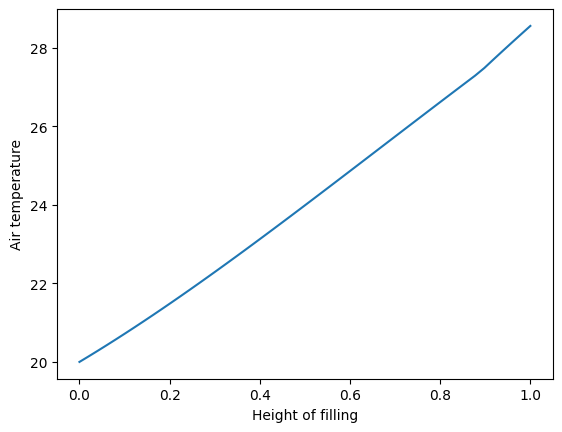

In [38]:
x = (df["water_temp_c"] - df["water_temp_c"].min())/(df["water_temp_c"].max() - df["water_temp_c"].min())
y = df["air_temp_c"]
plt.plot(x, y)
plt.xlabel("Height of filling")
plt.ylabel("Air temperature")

Humidity of air

Text(0, 0.5, 'Air humidity')

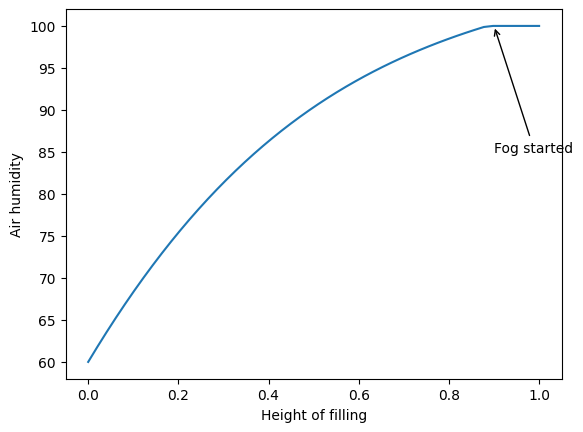

In [39]:
x = (df["water_temp_c"] - df["water_temp_c"].min())/(df["water_temp_c"].max() - df["water_temp_c"].min())
y = df["air_rh_perc"]
plt.plot(x, y)
plt.xlabel("Height of filling")
plt.annotate(
    "Fog started",
    xy=(0.9, 100),
    xycoords="data",
    xytext=(0.9, 85),
    textcoords="data",
    arrowprops=dict(arrowstyle="->")
)
plt.ylabel("Air humidity")

In [40]:
#what is inside results:
results

{'evaporation': np.float64(0.013518579034635008),
 'me': np.float64(1.255702249768176),
 'fog': np.float64(1.4783621300262669e-05),
 'fog_force': 12.0}

In [41]:
width = 70
print(f"{'Evaporation (real evaporation + fog drift):':<{width}} {results['evaporation']*100:>8.2f}%")
print(f"{'Merkel Number:':<{width}} {results['me']:>8.2f}")
print(f"{'Fog drift:':<{width}} {results['fog']*100:>8.2f}%")
print(f"{'Relative parameter to understand which part of filling in a fog area:':<{width}} {results['fog_force']:>8.2f}%")
print(f"{'Approach:':<{width}} {25.0 - solver.air_in.wet_bulb_temperature().magnitude:>8.2f}")

Evaporation (real evaporation + fog drift):                                1.35%
Merkel Number:                                                             1.26
Fog drift:                                                                 0.00%
Relative parameter to understand which part of filling in a fog area:     12.00%
Approach:                                                                  9.86


### According to Merkel theory $Me = C * (LG)^{-n}$, C and n are characteristics of cooling tower and comes from manufacturer. Let's assume n = 0.6. C is a parameter which can be used as a KPI of efficacy of cooling tower. 

In [42]:
C = results["me"]/LG_RATIO**(-0.6)
print(f"C = {C:.2f}")

C = 1.40


## Predicting of temperatures
Now we have C and n, our inlet temperature is 35C and outlet is 25C. Delta t = 10C defined by process (let say we have a condenser with stable heat load). What will happen weather becomes hotter?
Let assume that Air temperature is 40C and humidity is 40% and our requirements to cold water are 30C. We can use calculated merkel number because we will keep LG ratio the same

In [43]:
air = AirFlow(temp=Q_(40, u.degC), humidity=Q_(40, u.perc))
target_merkel = results["me"]
delta_t = Q_(10, u.degC)
lg_ratio = 1.2
water_salinity = Q_(1000, u.mg/u.kg)

In [44]:
t_in, t_out = PoppeSolver.find_temperatures_by_merkel(air_in=air, delta_temp=delta_t, lg_ratio=lg_ratio,target_merkel=target_merkel, water_salinity=water_salinity)

In [45]:
print(f"Temperature of hot water = {t_in.magnitude:.2f} C \n Temperature of cold water = {t_out.magnitude:.2f}")

Temperature of hot water = 42.52 C 
 Temperature of cold water = 32.52


In [46]:
solver = PoppeSolver(air_in=air, water_in=WaterFlow(temp=t_in,salinity=water_salinity), lg_ratio=lg_ratio, water_temp_out=t_out)
results = PoppeSolver.process_results(solver.solve())

In [50]:
width = 70
print(f"{'Evaporation (real evaporation + fog drift):':<{width}} {results['evaporation']*100:>8.2f}%")
print(f"{'Merkel Number:':<{width}} {results['me']:>8.2f}")
print(f"{'Fog drift:':<{width}} {results['fog']*100:>8.2f}%")
print(f"{'Relative parameter to understand which part of filling in a fog area:':<{width}} {results['fog_force']:>8.2f}%")
print(f"{'Approach:':<{width}} {(t_out - air.wet_bulb_temperature()).magnitude:>8.2f}")

Evaporation (real evaporation + fog drift):                                1.67%
Merkel Number:                                                             1.26
Fog drift:                                                                 0.00%
Relative parameter to understand which part of filling in a fog area:      0.00%
Approach:                                                                  4.69


Approach was 9.9 C and become 4.7. But efficacy of cooling tower is the same